In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

In [2]:
# Enable automatic reloading of modules before executing cells
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR = os.getcwd()
PARENT_DIR = os.path.dirname(SCRIPT_DIR)
ML_DIR = os.path.join(PARENT_DIR, "ml_scripts")
DATA_DIR = os.path.join(ML_DIR, "output")
ENSEMBLE_DATA_DIR = os.path.join(DATA_DIR, "ensemble")
POST_PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "2030_emissions")

In [4]:
# Load the data
run_id = 1773188058
iso_alpha_3 = "MEX"
df = pd.read_parquet(os.path.join(POST_PROCESSED_DATA_DIR, f"post_processed_projected_emissions_{run_id}.parquet"))
df.head()


,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,29.511985
2,id_AFG_10,AFG,2024,30.435955
3,id_AFG_10,AFG,2025,31.448054
4,id_AFG_10,AFG,2026,32.404918


In [5]:
# Filter the data for the specific country
df = df[df["iso_alpha_3"] == iso_alpha_3]

### Compute Change and Create Labels

In [7]:
# First compute percentage difference between final year and 2022.

def compute_emissions_change(df, year1, year2, value_col):
    df_pivot = df.pivot(index=["future_id", "iso_alpha_3"], columns="year", values=value_col).reset_index()
    df_pivot.columns.name = None

    # ensure all column names are strings
    df_pivot.columns = df_pivot.columns.astype(str)

    # Create vulnerability_indicator field
    df_pivot["vulnerability_indicator"] = (df_pivot[year2] > df_pivot[year1]).astype(int)

    df_pivot = df_pivot[["future_id", "iso_alpha_3", year1, year2, "vulnerability_indicator"]]
    return df_pivot

df_pivot = compute_emissions_change(df, "2022", "2030", "con_edgar_ghg_mt_hp_trend")
df_pivot.head()

,future_id,iso_alpha_3,2022,2030,vulnerability_indicator
0,id_MEX_1,MEX,787.671094,764.184443,0
1,id_MEX_10,MEX,787.671094,796.694486,1
2,id_MEX_100,MEX,787.671094,797.843480,1
3,id_MEX_1000,MEX,787.671094,829.957313,1
4,id_MEX_101,MEX,787.671094,874.880029,1


/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000gn/T/ipykernel_75812/3028537570.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=vuln_col, data=df, palette=palette, order=order, ax=ax_local)


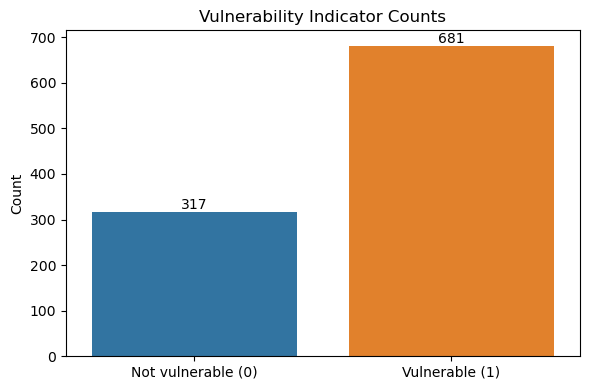

In [13]:
def plot_vulnerability_counts(
    df,
    vuln_col="vulnerability_indicator",
    figsize=(6, 4),
    palette=None,
    xtick_labels=None,
    xlabel="",
    ylabel="Count",
    title="Vulnerability Indicator Counts",
    annotate=True,
    order=None,
    show=True
):
    """
    Plot a simple annotated countplot for a binary vulnerability column.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing the vulnerability column.
    vuln_col : str
        Column name with binary indicator (expected values like 0 and 1).
    figsize : tuple
        Figure size.
    palette : list or dict
        Colors for bars.
    xtick_labels : list
        Labels for x ticks (same order as `order`).
    xlabel, ylabel, title : str
        Axis and title text.
    annotate : bool
        Whether to annotate bar counts.
    order : list
        Explicit order of categories to plot (e.g., [0, 1]).
    show : bool
        Whether to call plt.show() before returning the axis.

    Returns
    -------
    matplotlib.axes.Axes
        The axes object of the created plot.
    """
    if vuln_col not in df.columns:
        raise ValueError(f"Column '{vuln_col}' not found in dataframe.")

    palette = palette or ["tab:blue", "tab:orange"]

    # determine order of categories
    if order is None:
        order = sorted(df[vuln_col].dropna().unique().tolist())

    # default xtick labels for binary 0/1
    if xtick_labels is None:
        if set(order) == {0, 1}:
            xtick_labels = ["Not vulnerable (0)", "Vulnerable (1)"]
        else:
            xtick_labels = [str(v) for v in order]

    plt.figure(figsize=figsize)
    ax_local = plt.gca()
    sns.countplot(x=vuln_col, data=df, palette=palette, order=order, ax=ax_local)
    ax_local.set_xticks(range(len(order)))
    ax_local.set_xticklabels(xtick_labels)
    ax_local.set_ylabel(ylabel)
    ax_local.set_xlabel(xlabel)
    ax_local.set_title(title)

    if annotate:
        for p in ax_local.patches:
            height = p.get_height()
            ax_local.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2, height),
                ha="center",
                va="bottom"
            )

    plt.tight_layout()
    if show:
        plt.show()
    return ax_local

# Example usage
ax = plot_vulnerability_counts(df_pivot)

### Aggregate ARIMA data

In [14]:
# Load the projected data
ensemble_df = pd.read_parquet(os.path.join(ENSEMBLE_DATA_DIR, f"ensemble_arima_{run_id}.parquet"))
ensemble_df.head()

,iso_alpha_3,future_id,year,x_log_signed_con_edgar_ghg_mt,x_log_signed_con_solar,inc_has_efficiency_standard,inc_has_renewable_target,con_net_elec_imports_twh,x_log_signed_cap_civil_liberties_idx,inc_has_carbon_tax,...,cap_govt_effectiveness,con_ndgain_score,emissions_anchor_2022,years_since_2022,trend_year_interaction,em_lag_1y,em_trend_3y,em_trend_5y,em_volatility_5y,em_acceleration
0,AFG,id_AFG_1,2022,3.405119,0.048790,0.0,0.0,5.880000,0.040182,0.0,...,-1.880035,32.633596,NaN,0.0,NaN,3.399653,-0.022348,-0.028681,0.050438,0.006334
1,AFG,id_AFG_1,2023,3.406011,0.055667,0.0,0.0,6.009763,0.000000,0.0,...,-2.028122,32.452377,NaN,1.0,NaN,3.400199,-0.018481,-0.027746,0.049581,0.006627
2,AFG,id_AFG_1,2024,3.395691,0.063294,0.0,0.0,6.157955,0.000000,0.0,...,-2.189786,33.519214,NaN,2.0,NaN,3.400289,-0.019795,-0.026254,0.047960,0.006346
3,AFG,id_AFG_1,2025,3.384084,0.070110,0.0,0.0,6.515455,0.000000,0.0,...,-2.319343,33.014896,NaN,3.0,NaN,3.399257,-0.020584,-0.025285,0.046763,0.006171
4,AFG,id_AFG_1,2026,3.391456,0.071661,0.0,0.0,6.538660,0.000000,0.0,...,-2.482714,34.419108,NaN,4.0,NaN,3.398096,-0.021209,-0.026219,0.046283,0.006201


In [15]:
ensemble_df.columns

Index(['iso_alpha_3', 'future_id', 'year', 'x_log_signed_con_edgar_ghg_mt',
       'x_log_signed_con_solar', 'inc_has_efficiency_standard',
       'inc_has_renewable_target', 'con_net_elec_imports_twh',
       'x_log_signed_cap_civil_liberties_idx', 'inc_has_carbon_tax',
       'inc_has_ets', 'x_log_signed_inc_carbon_pricing_coverage',
       'con_forest_area_pct', 'con_agricultural_land_pct',
       'x_log_signed_con_nuclear', 'x_log_signed_con_electricity_access_pct',
       'inc_has_framework_law', 'x_log_signed_inc_n_climate_laws',
       'x_log_signed_inc_cumulative_climate_laws', 'con_fossil_share_elec_pct',
       'con_renewables_share_elec_pct', 'x_log_signed_con_primary_energy_twh',
       'x_log_signed_con_hydro', 'x_log_signed_con_demand',
       'x_log_signed_con_coal', 'x_log_signed_con_gas',
       'x_log_signed_con_demand_per_capita', 'cap_regulatory_quality',
       'cap_rule_of_law', 'cap_govt_effectiveness', 'con_ndgain_score',
       'emissions_anchor_2022', 'years_s

In [16]:
# Aggregate ensemble data so we only get a single row per future_id

# First we remove all emisssion-related variables to avoid any sort of leakage
emission_cols = [
    'x_log_signed_con_edgar_ghg_mt',
    'emissions_anchor_2022', 
    'years_since_2022', 
    'trend_year_interaction',
    'em_lag_1y',
    'em_trend_3y',
    'em_trend_5y',
    'em_volatility_5y',
    'em_acceleration'
]

ensemble_df = ensemble_df.drop(columns=emission_cols, errors='ignore')

# Filter to only the country we're interested in
ensemble_df = ensemble_df[ensemble_df["iso_alpha_3"] == iso_alpha_3]

# Now we aggregate

def load_projection_rulebook(rules_path):
    with open(rules_path, 'r') as f:
        rulebook = json.load(f)

    category_map = {}
    for category, columns in rulebook.get('categories', {}).items():
        for col in columns:
            category_map[col] = category

    for col, category in rulebook.get('overrides', {}).items():
        category_map[col] = category

    prefix_rules = rulebook.get('prefix_rules', [])
    default_category = rulebook.get('default_category', 'unconstrained')
    return category_map, prefix_rules, default_category

def resolve_category(col, category_map, prefix_rules, default_category):
    if col in category_map:
        return category_map[col]
    for rule in prefix_rules:
        if col.startswith(rule['prefix']):
            return rule['category']
    return default_category

def _safe_std(values):
    if len(values) <= 1:
        return np.nan
    return float(np.std(values, ddof=1))

def _safe_slope(years, values):
    if len(values) <= 1:
        return np.nan
    return float(np.polyfit(years.astype(float), values.astype(float), 1)[0])

def summarize_trajectory(group, value_cols, category_map, prefix_rules, default_category):
    group = group.sort_values('year')
    row = {
        'future_id': group['future_id'].iloc[0],
        'iso_alpha_3': group['iso_alpha_3'].iloc[0],
        'year_start': int(group['year'].min()),
        'year_end': int(group['year'].max()),
        'n_years': int(group['year'].nunique()),
    }

    for col in value_cols:
        category = resolve_category(col, category_map, prefix_rules, default_category)
        valid = group[['year', col]].dropna()

        if valid.empty:
            continue

        years = valid['year'].to_numpy()
        values = valid[col].astype(float).to_numpy()
        prefix = f'{col}__'

        if category == 'binary':
            row[prefix + 'mean'] = float(values.mean())
            row[prefix + 'last'] = float(values[-1])
            row[prefix + 'max'] = float(values.max())
            row[prefix + 'switches'] = float(np.abs(np.diff(values)).sum()) if len(values) > 1 else 0.0
        elif category == 'cumulative_binary':
            row[prefix + 'last'] = float(values[-1])
            row[prefix + 'max'] = float(values.max())
        elif category == 'count':
            row[prefix + 'sum'] = float(values.sum())
            row[prefix + 'mean'] = float(values.mean())
            row[prefix + 'std'] = _safe_std(values)
            row[prefix + 'max'] = float(values.max())
            row[prefix + 'last'] = float(values[-1])
            row[prefix + 'delta'] = float(values[-1] - values[0])
            row[prefix + 'slope'] = _safe_slope(years, values)
        elif category == 'cumulative_count':
            row[prefix + 'last'] = float(values[-1])
            row[prefix + 'max'] = float(values.max())
            row[prefix + 'delta'] = float(values[-1] - values[0])
            row[prefix + 'slope'] = _safe_slope(years, values)
        else:
            row[prefix + 'mean'] = float(values.mean())
            row[prefix + 'std'] = _safe_std(values)
            row[prefix + 'min'] = float(values.min())
            row[prefix + 'max'] = float(values.max())
            row[prefix + 'last'] = float(values[-1])
            row[prefix + 'delta'] = float(values[-1] - values[0])
            row[prefix + 'slope'] = _safe_slope(years, values)

    return row

def aggregate_ensemble_by_future_id(
    ensemble_df,
    rules_path,
    group_col='future_id',
    keep_country_col='iso_alpha_3',
    year_col='year'
):
    category_map, prefix_rules, default_category = load_projection_rulebook(rules_path)

    id_cols = {group_col, keep_country_col, year_col}
    value_cols = [col for col in ensemble_df.columns if col not in id_cols]

    aggregated_rows = []
    for _, group in ensemble_df.groupby(group_col, sort=False):
        aggregated_rows.append(
            summarize_trajectory(group, value_cols, category_map, prefix_rules, default_category)
        )

    return pd.DataFrame(aggregated_rows)

rules_path = os.path.join(ML_DIR, 'config', 'variable_projection_rules.json')
ensemble_agg_df = aggregate_ensemble_by_future_id(ensemble_df, rules_path=rules_path)
ensemble_agg_df.head()

,future_id,iso_alpha_3,year_start,year_end,n_years,x_log_signed_con_solar__mean,x_log_signed_con_solar__std,x_log_signed_con_solar__min,x_log_signed_con_solar__max,x_log_signed_con_solar__last,...,cap_govt_effectiveness__last,cap_govt_effectiveness__delta,cap_govt_effectiveness__slope,con_ndgain_score__mean,con_ndgain_score__std,con_ndgain_score__min,con_ndgain_score__max,con_ndgain_score__last,con_ndgain_score__delta,con_ndgain_score__slope
0,id_MEX_1,MEX,2022,2030,9,2.888264,0.316017,2.337952,3.228861,3.153228,...,-0.690586,-0.408863,-0.049805,45.187459,0.695513,43.916781,46.050706,45.399561,-0.346462,0.105335
1,id_MEX_10,MEX,2022,2030,9,3.076343,0.539645,2.337952,3.773056,3.773056,...,-0.916191,-0.634467,-0.078832,44.884441,1.500822,42.768358,47.752418,43.749064,-1.996959,-0.426157
2,id_MEX_100,MEX,2022,2030,9,2.268672,0.202818,1.993121,2.685267,2.685267,...,-0.378619,-0.096895,-0.012931,47.591395,3.149055,43.823727,52.783868,43.823727,-1.922296,-0.609375
3,id_MEX_1000,MEX,2022,2030,9,2.385828,0.210126,2.089729,2.625595,2.089729,...,-0.310199,-0.028475,-0.007892,44.017637,1.890886,41.537287,47.178064,41.537287,-4.208736,-0.379388
4,id_MEX_101,MEX,2022,2030,9,2.886270,0.296989,2.337952,3.300821,3.300821,...,-0.700028,-0.418304,-0.046117,45.301093,0.842952,44.060642,46.294423,44.899142,-0.846880,0.026911


In [17]:
ensemble_agg_df.columns

Index(['future_id', 'iso_alpha_3', 'year_start', 'year_end', 'n_years',
       'x_log_signed_con_solar__mean', 'x_log_signed_con_solar__std',
       'x_log_signed_con_solar__min', 'x_log_signed_con_solar__max',
       'x_log_signed_con_solar__last',
       ...
       'cap_govt_effectiveness__last', 'cap_govt_effectiveness__delta',
       'cap_govt_effectiveness__slope', 'con_ndgain_score__mean',
       'con_ndgain_score__std', 'con_ndgain_score__min',
       'con_ndgain_score__max', 'con_ndgain_score__last',
       'con_ndgain_score__delta', 'con_ndgain_score__slope'],
      dtype='object', length=177)

In [18]:
df_pivot.head()

,future_id,iso_alpha_3,2022,2030,vulnerability_indicator
0,id_MEX_1,MEX,787.671094,764.184443,0
1,id_MEX_10,MEX,787.671094,796.694486,1
2,id_MEX_100,MEX,787.671094,797.843480,1
3,id_MEX_1000,MEX,787.671094,829.957313,1
4,id_MEX_101,MEX,787.671094,874.880029,1


In [19]:
# Merge the ensemble agg data with the quantile-labeled data
def merge_ensemble_with_vulnerability(ensemble_agg_df, vulnerability_df, on_cols=["future_id"]):
    merged_df = pd.merge(ensemble_agg_df, vulnerability_df, on=on_cols, how="left")
    # ensure the bin cols are integers (in case they got cast to floats during the merge)
    # use the nullable integer dtype so NaNs are preserved instead of raising on conversion
    for col in vulnerability_df.columns:
        if col.startswith("v"):
            # coerce non-finite values to NaN, then cast to pandas nullable integer dtype
            merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce").astype("Int64")

    return merged_df
merged_df = merge_ensemble_with_vulnerability(ensemble_agg_df, df_pivot, on_cols=["future_id", "iso_alpha_3"])
merged_df.head()

,future_id,iso_alpha_3,year_start,year_end,n_years,x_log_signed_con_solar__mean,x_log_signed_con_solar__std,x_log_signed_con_solar__min,x_log_signed_con_solar__max,x_log_signed_con_solar__last,...,con_ndgain_score__mean,con_ndgain_score__std,con_ndgain_score__min,con_ndgain_score__max,con_ndgain_score__last,con_ndgain_score__delta,con_ndgain_score__slope,2022,2030,vulnerability_indicator
0,id_MEX_1,MEX,2022,2030,9,2.888264,0.316017,2.337952,3.228861,3.153228,...,45.187459,0.695513,43.916781,46.050706,45.399561,-0.346462,0.105335,787.671094,764.184443,0
1,id_MEX_10,MEX,2022,2030,9,3.076343,0.539645,2.337952,3.773056,3.773056,...,44.884441,1.500822,42.768358,47.752418,43.749064,-1.996959,-0.426157,787.671094,796.694486,1
2,id_MEX_100,MEX,2022,2030,9,2.268672,0.202818,1.993121,2.685267,2.685267,...,47.591395,3.149055,43.823727,52.783868,43.823727,-1.922296,-0.609375,787.671094,797.843480,1
3,id_MEX_1000,MEX,2022,2030,9,2.385828,0.210126,2.089729,2.625595,2.089729,...,44.017637,1.890886,41.537287,47.178064,41.537287,-4.208736,-0.379388,787.671094,829.957313,1
4,id_MEX_101,MEX,2022,2030,9,2.886270,0.296989,2.337952,3.300821,3.300821,...,45.301093,0.842952,44.060642,46.294423,44.899142,-0.846880,0.026911,787.671094,874.880029,1


In [20]:
merged_df.columns

Index(['future_id', 'iso_alpha_3', 'year_start', 'year_end', 'n_years',
       'x_log_signed_con_solar__mean', 'x_log_signed_con_solar__std',
       'x_log_signed_con_solar__min', 'x_log_signed_con_solar__max',
       'x_log_signed_con_solar__last',
       ...
       'con_ndgain_score__mean', 'con_ndgain_score__std',
       'con_ndgain_score__min', 'con_ndgain_score__max',
       'con_ndgain_score__last', 'con_ndgain_score__delta',
       'con_ndgain_score__slope', '2022', '2030', 'vulnerability_indicator'],
      dtype='object', length=180)

### Train ML Model

/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000gn/T/ipykernel_75812/632375212.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=top_features_df, palette="viridis")


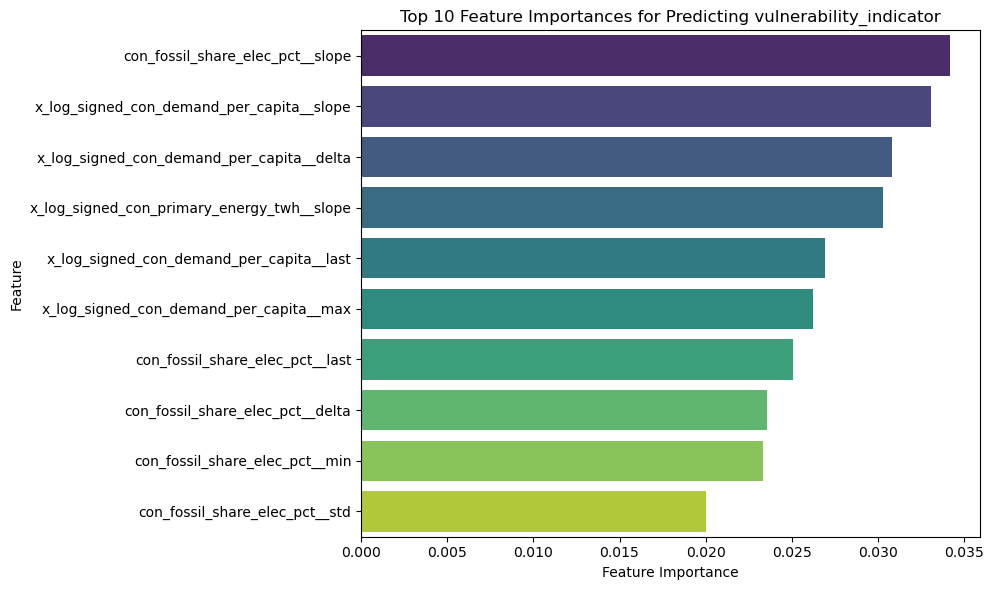

,target_col,n_rows,n_train,n_test,class_0,class_1,status,n_features,baseline_accuracy,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,mean_importance,median_importance,max_importance
0,vulnerability_indicator,998,798,200,317,681,trained,172,0.68,0.805,0.740809,0.816993,0.919118,0.865052,0.920496,0.005814,0.003273,0.034196


In [ ]:
# Then we train the rando forests to predict each of the binary variables and we compute the feature importance.
# We only care about those that are above 0.5 feature importance.

# Filter out irrelevant columns for modeling
non_modeling_cols = [
    "future_id",
    "iso_alpha_3",
    "year_start",
    "year_end",
    "n_years",
    "2022",
    "2030",
]

target_col = "vulnerability_indicator"
feature_cols = [col for col in merged_df.columns if col not in non_modeling_cols + [target_col]]

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import numpy as np

# Prepare data
X_all = merged_df[feature_cols].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(merged_df[target_col], errors="coerce")
valid_mask = y.notna()

X_target = X_all.loc[valid_mask].copy()
y_target = y.loc[valid_mask].astype(int)

rf_models = {}
rf_training_rows = []
feature_importance_rows = []
test_size = 0.2  # keep existing value

# Only one target_col expected; skip training if insufficient data or classes
if X_target.empty or y_target.nunique() < 2:
    rf_training_rows.append({
        "target_col": target_col,
        "n_rows": int(len(y_target)),
        "class_0": int((y_target == 0).sum()),
        "class_1": int((y_target == 1).sum()),
        "status": "skipped_insufficient_rows_or_classes"
    })
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_target,
        y_target,
        test_size=test_size,
        random_state=42,
        stratify=y_target
    )

    eval_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample",
            min_samples_leaf=2
        ))
    ])

    eval_model.fit(X_train, y_train)
    y_pred = eval_model.predict(X_test)
    y_proba = eval_model.predict_proba(X_test)[:, 1]

    final_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample",
            min_samples_leaf=2
        ))
    ])
    final_model.fit(X_target, y_target)
    rf_models[target_col] = final_model

    rf = final_model.named_steps["rf"]
    importances = rf.feature_importances_
    max_importance = float(importances.max()) if importances.size else np.nan
    mean_importance = float(importances.mean()) if importances.size else np.nan
    median_importance = float(np.median(importances)) if importances.size else np.nan
    baseline_accuracy = float(max((y_test == 0).mean(), (y_test == 1).mean()))
    roc_auc = float(roc_auc_score(y_test, y_proba)) if y_test.nunique() == 2 else np.nan

    rf_training_rows.append({
        "target_col": target_col,
        "n_rows": int(len(y_target)),
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "class_0": int((y_target == 0).sum()),
        "class_1": int((y_target == 1).sum()),
        "status": "trained",
        "n_features": int(len(feature_cols)),
        "baseline_accuracy": baseline_accuracy,
        "test_accuracy": float(accuracy_score(y_test, y_pred)),
        "test_balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
        "test_precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "test_recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "test_f1": float(f1_score(y_test, y_pred, zero_division=0)),
        "test_roc_auc": roc_auc,
        "mean_importance": mean_importance,
        "median_importance": median_importance,
        "max_importance": max_importance,
    })

    for feature_name, importance in zip(feature_cols, importances):
        feature_importance_rows.append({
            "target_col": target_col,
            "feature": feature_name,
            "importance": float(importance),
        })

rf_training_summary_df = pd.DataFrame(rf_training_rows).sort_values("target_col").reset_index(drop=True)
feature_importance_df = pd.DataFrame(feature_importance_rows)

/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000gn/T/ipykernel_75812/363090619.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=top_features_df, palette="viridis")


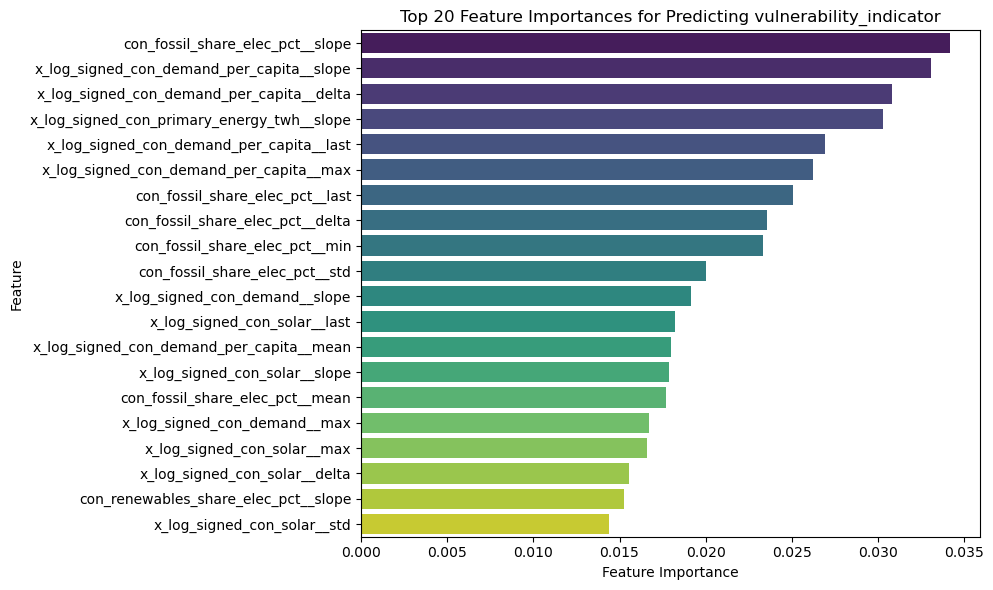

,target_col,n_rows,n_train,n_test,class_0,class_1,status,n_features,baseline_accuracy,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,mean_importance,median_importance,max_importance
0,vulnerability_indicator,998,798,200,317,681,trained,172,0.68,0.805,0.740809,0.816993,0.919118,0.865052,0.920496,0.005814,0.003273,0.034196


In [38]:
# Plot top 10 features by importance for the target variable
top_n = 20
top_features_df = (
    feature_importance_df[feature_importance_df["target_col"] == target_col]
    .sort_values("importance", ascending=False)
    .head(top_n)
)

#plotting
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=top_features_df, palette="viridis")
plt.title(f"Top {top_n} Feature Importances for Predicting {target_col}")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

rf_training_summary_df


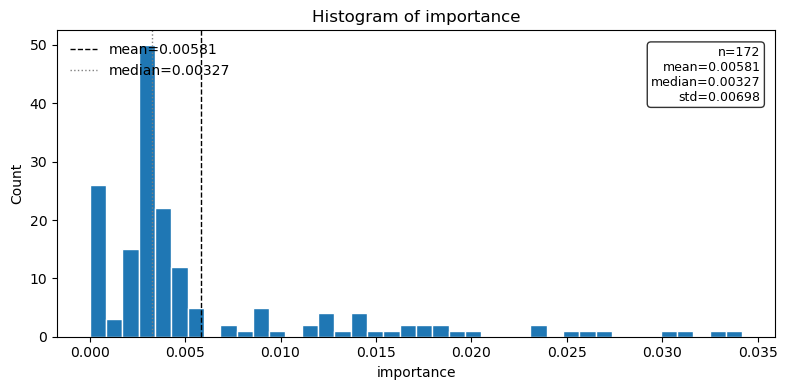

<Axes: title={'center': 'Histogram of importance'}, xlabel='importance', ylabel='Count'>

In [40]:
def plot_histogram(
    df,
    column,
    bins=30,
    figsize=(8, 4),
    color="tab:blue",
    kde=False,
    log_scale=False,
    xlabel=None,
    ylabel="Count",
    title=None,
    annotate_stats=True,
    dropna=True,
    rug=False,
    show=True,
):
    """
    Plot a simple histogram for a dataframe column.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing the column to plot.
    column : str
        Column name to plot.
    bins : int or sequence
        Number of bins or bin edges for the histogram.
    figsize : tuple
        Figure size.
    color : str
        Bar color.
    kde : bool
        Whether to overlay a KDE (uses seaborn).
    log_scale : bool
        Whether to use a log scale on the x axis.
    xlabel, ylabel, title : str or None
        Axis and title labels.
    annotate_stats : bool
        Annotate mean, median and non-null count on the plot.
    dropna : bool
        Drop NA values before plotting.
    rug : bool
        Add a rug plot (seaborn).
    show : bool
        Whether to call plt.show() before returning the axis.

    Returns
    -------
    matplotlib.axes.Axes
        The axes object of the plot.
    """
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in dataframe.")

    data = df[column]
    if dropna:
        data = data.dropna()

    plt.figure(figsize=figsize)
    ax = plt.gca()

    # use seaborn histogram for consistency; fall back to plt.hist if needed
    try:
        sns.histplot(data, bins=bins, color=color, kde=kde, ax=ax, edgecolor="w", stat="count", rug=rug)
    except Exception:
        ax.hist(data, bins=bins, color=color, edgecolor="w")

    if log_scale:
        ax.set_xscale("log")

    ax.set_xlabel(xlabel or column)
    ax.set_ylabel(ylabel)
    ax.set_title(title or f"Histogram of {column}")

    if annotate_stats and len(data) > 0:
        mean = float(data.mean())
        median = float(data.median())
        std = float(data.std())
        n = int(data.count())

        # vertical lines
        ax.axvline(mean, color="k", linestyle="--", linewidth=1, label=f"mean={mean:.3g}")
        ax.axvline(median, color="gray", linestyle=":", linewidth=1, label=f"median={median:.3g}")

        # text annotation in upper right
        text = f"n={n}\nmean={mean:.3g}\nmedian={median:.3g}\nstd={std:.3g}"
        ax.text(0.98, 0.95, text, transform=ax.transAxes, ha="right", va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8), fontsize=9)

        ax.legend(loc="upper left", frameon=False)

    plt.tight_layout()
    if show:
        plt.show()

    return ax


# Example usage (uses variables already present in the notebook):
plot_histogram(feature_importance_df, "importance", bins=40, kde=False, annotate_stats=True)

### Select Top Features and Create Box Plot

In [34]:
# Add to feature_name to top_feature_counts_df
feature_importance_df['feature_standard_name'] = feature_importance_df["feature"].apply(lambda x: x.split("__")[0] if "__" in x else x)

# sort by importance to see top features
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)
feature_importance_df.head(20)

,target_col,feature,importance,feature_standard_name
94,vulnerability_indicator,con_fossil_share_elec_pct__slope,0.034196,con_fossil_share_elec_pct
143,vulnerability_indicator,x_log_signed_con_demand_per_capita__slope,0.033073,x_log_signed_con_demand_per_capita
142,vulnerability_indicator,x_log_signed_con_demand_per_capita__delta,0.030842,x_log_signed_con_demand_per_capita
108,vulnerability_indicator,x_log_signed_con_primary_energy_twh__slope,0.030311,x_log_signed_con_primary_energy_twh
141,vulnerability_indicator,x_log_signed_con_demand_per_capita__last,0.026954,x_log_signed_con_demand_per_capita
140,vulnerability_indicator,x_log_signed_con_demand_per_capita__max,0.026259,x_log_signed_con_demand_per_capita
92,vulnerability_indicator,con_fossil_share_elec_pct__last,0.025087,con_fossil_share_elec_pct
93,vulnerability_indicator,con_fossil_share_elec_pct__delta,0.023583,con_fossil_share_elec_pct
90,vulnerability_indicator,con_fossil_share_elec_pct__min,0.023323,con_fossil_share_elec_pct
89,vulnerability_indicator,con_fossil_share_elec_pct__std,0.019993,con_fossil_share_elec_pct


In [35]:
# Select the top 2 features making sure we don't select multiple features that are just different aggregations of the same underlying variable (e.g. mean, max, last of the same variable)
selected_features = []
for _, row in feature_importance_df.iterrows():
    feature_name = row["feature_standard_name"]
    if feature_name not in selected_features:
        selected_features.append(feature_name)
    if len(selected_features) >= 2:
        break
print("Selected features for scenario discovery:", selected_features)

Selected features for scenario discovery: ['con_fossil_share_elec_pct', 'x_log_signed_con_demand_per_capita']


In [36]:
def plot_xy_by_vulnerability(
    df: pd.DataFrame,
    x, y,
    vuln_col: str = "vulnerability_indicator",
    threshold_col: str | None = None,
    threshold_value: float | int | None = None,
    labels: dict = None,
    colors: dict = None,
    markers: dict = None,
    s: int = 60,
    alpha: float = 0.8,
    title: str | None = None,
):
    """
    Scatter plot of df[x] vs df[y], styled by binary vulnerability_indicator.

    Parameters
    ----------
    df : pd.DataFrame
    x, y : str or int
        Column names or integer indices for x and y.
    vuln_col : str
        Column with binary indicator {0, 1}.
    threshold_col : str | None
        Optional column name to filter on (e.g., 'vulnerability_threshold').
    threshold_value : float | int | None
        Optional value to filter threshold_col by (e.g., 0.3).
    labels : dict
        Optional mapping {0: "Not vulnerable", 1: "Vulnerable"} for legend.
    colors : dict
        Optional mapping {0: <color>, 1: <color>}.
    markers : dict
        Optional mapping {0: <marker>, 1: <marker>}.
    s : int
        Marker size.
    alpha : float
        Marker transparency.
    title : str | None
        Plot title.
    """

    # Resolve column names if user passed integer indices
    x_col = df.columns[x] if isinstance(x, int) else x
    y_col = df.columns[y] if isinstance(y, int) else y

    # Optional filtering by threshold
    data = df
    if threshold_col is not None and threshold_value is not None:
        data = data[data[threshold_col] == threshold_value]

    # Drop rows with missing required values
    data = data[[x_col, y_col, vuln_col]].dropna()

    # Validate binary
    uniq = np.sort(data[vuln_col].unique())
    if not set(uniq).issubset({0, 1}):
        raise ValueError(f"'{vuln_col}' must be binary {{0,1}}; got {uniq}.")

    # Defaults
    labels = labels or {0: "Not vulnerable (0)", 1: "Vulnerable (1)"}
    colors = colors or {0: "tab:blue", 1: "tab:orange"}
    markers = markers or {0: "o", 1: "X"}

    # Title
    if title is None:
        title = f"{x_col} vs {y_col} by {vuln_col}"
        if threshold_col and threshold_value is not None:
            title += f" | {threshold_col} = {threshold_value}"

    # Plot
    plt.figure(figsize=(8, 6))
    for v in [0, 1]:
        subset = data[data[vuln_col] == v]
        if subset.empty:
            continue
        plt.scatter(
            subset[x_col],
            subset[y_col],
            s=s,
            alpha=alpha,
            edgecolor="k",
            color=colors.get(v, "gray"),
            marker=markers.get(v, "o"),
            label=labels.get(v, str(v)),
        )

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(title=vuln_col)
    plt.tight_layout()
    plt.show()

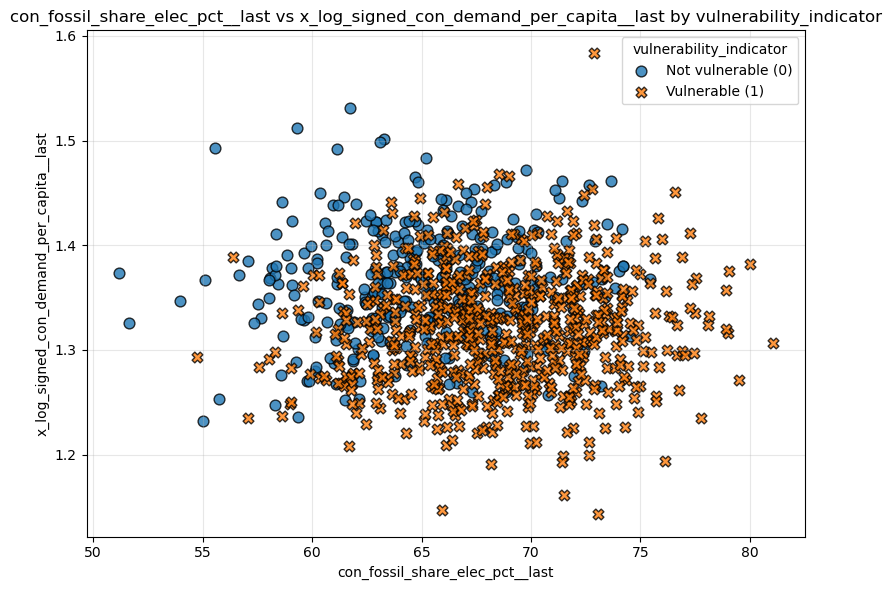

In [37]:
plot_xy_by_vulnerability(merged_df,
                         x=selected_features[0] + "__last",
                         y=selected_features[1] + "__last",
                         vuln_col="vulnerability_indicator",)